## Мониторинг физической активности — кластеризация без учителя

**Цель:** сгруппировать данные с носимых датчиков по типам активности

В этой задаче необходимо кластеризовать данные, собранные с носимых устройств, на группы по типу физической активности. В предоставленном файле нет целевой переменной `activityID`, поэтому задача решается как **обучение без учителя**.

**Цель проекта:**

1. исследовать и проанализировать датасет;
2. выполнить предобработку данных;
3. создать дополнительные признаки на основе физического смысла IMU-измерений;
4. сравнить несколько моделей кластеризации;
5. выбрать лучшую модель;
6. сформировать файл `submission.csv` для Kaggle в формате

## 0. Импорт библиотек и настройки


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from pandas.plotting import scatter_matrix

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, DBSCAN, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


import missingno as msno


warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Загрузка данных


In [2]:
data = pd.read_csv('/content/Physical_Activity_Monitoring_unlabeled.csv')

## 2. EDA Исследование данных

Проверяем типы данных, пропуски и дубликаты. Это нужно, чтобы понять данные до предобработки и выбрать корректные методы заполнения пропусков и масштабирования.


In [3]:
print("Размер данных:", data.shape)
print("Колонки:")
print(data.columns.tolist())


Размер данных: (534601, 53)
Колонки:
['timestamp', 'handTemperature', 'handAcc16_1', 'handAcc16_2', 'handAcc16_3', 'handAcc6_1', 'handAcc6_2', 'handAcc6_3', 'handGyro1', 'handGyro2', 'handGyro3', 'handMagne1', 'handMagne2', 'handMagne3', 'handOrientation1', 'handOrientation2', 'handOrientation3', 'handOrientation4', 'chestTemperature', 'chestAcc16_1', 'chestAcc16_2', 'chestAcc16_3', 'chestAcc6_1', 'chestAcc6_2', 'chestAcc6_3', 'chestGyro1', 'chestGyro2', 'chestGyro3', 'chestMagne1', 'chestMagne2', 'chestMagne3', 'chestOrientation1', 'chestOrientation2', 'chestOrientation3', 'chestOrientation4', 'ankleTemperature', 'ankleAcc16_1', 'ankleAcc16_2', 'ankleAcc16_3', 'ankleAcc6_1', 'ankleAcc6_2', 'ankleAcc6_3', 'ankleGyro1', 'ankleGyro2', 'ankleGyro3', 'ankleMagne1', 'ankleMagne2', 'ankleMagne3', 'ankleOrientation1', 'ankleOrientation2', 'ankleOrientation3', 'ankleOrientation4', 'subject_id']


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534601 entries, 0 to 534600
Data columns (total 53 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          534601 non-null  float64
 1   handTemperature    530560 non-null  float64
 2   handAcc16_1        530560 non-null  float64
 3   handAcc16_2        530560 non-null  float64
 4   handAcc16_3        530560 non-null  float64
 5   handAcc6_1         530560 non-null  float64
 6   handAcc6_2         530560 non-null  float64
 7   handAcc6_3         530560 non-null  float64
 8   handGyro1          530560 non-null  float64
 9   handGyro2          530560 non-null  float64
 10  handGyro3          530560 non-null  float64
 11  handMagne1         530560 non-null  float64
 12  handMagne2         530560 non-null  float64
 13  handMagne3         530560 non-null  float64
 14  handOrientation1   530560 non-null  float64
 15  handOrientation2   530560 non-null  float64
 16  ha

In [5]:
data.tail()

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
534596,3479.53,33.8750,-9.08425,4.70122,2.89017,-9.68961,6.78077,3.97543,-0.157406,0.774189,...,0.424520,-0.856836,-25.00990,-23.5557,23.615300,0.318171,-0.701921,0.555778,-0.311745,5
534597,2448.49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.767710,-3.050980,-35.70240,31.8018,16.421800,0.435887,0.660643,0.371665,0.485200,5
534598,2479.84,34.6875,-6.36755,2.32131,2.20764,-6.36246,2.33049,2.60761,0.206349,-0.359415,...,-0.034144,-0.402013,-49.69220,20.6039,-0.917908,0.561652,0.297957,0.756767,0.151899,5
534599,3437.82,28.0625,5.46194,10.43640,-9.07330,8.34886,5.76518,-6.14321,3.543910,2.757300,...,0.352062,-5.577750,-34.15510,-11.0786,39.737500,0.062163,-0.798705,-0.056668,-0.595815,6
534600,811.75,33.3125,-9.22591,2.00606,2.62773,-9.07646,1.97274,2.83768,-0.001754,-0.017191,...,-0.016041,0.005842,-1.01141,-16.4092,15.181500,0.324008,-0.710975,0.227375,-0.581235,4


In [6]:
print("Количество дубликатов:", data.duplicated().sum())


Количество дубликатов: 0


In [7]:
data.isna()

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
534596,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
534597,False,True,True,True,True,True,True,True,True,True,...,False,False,False,False,False,False,False,False,False,False
534598,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
534599,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
missing=np.round(data.isna().sum()[data.isna().sum()>0] / data.shape[0], 2)
missing

,0
handTemperature,0.01
handAcc16_1,0.01
handAcc16_2,0.01
handAcc16_3,0.01
handAcc6_1,0.01
handAcc6_2,0.01
handAcc6_3,0.01
handGyro1,0.01
handGyro2,0.01
handGyro3,0.01


In [9]:
print("Количество колонок с пропусками:", len(missing))

Количество колонок с пропусками: 51


<Axes: >

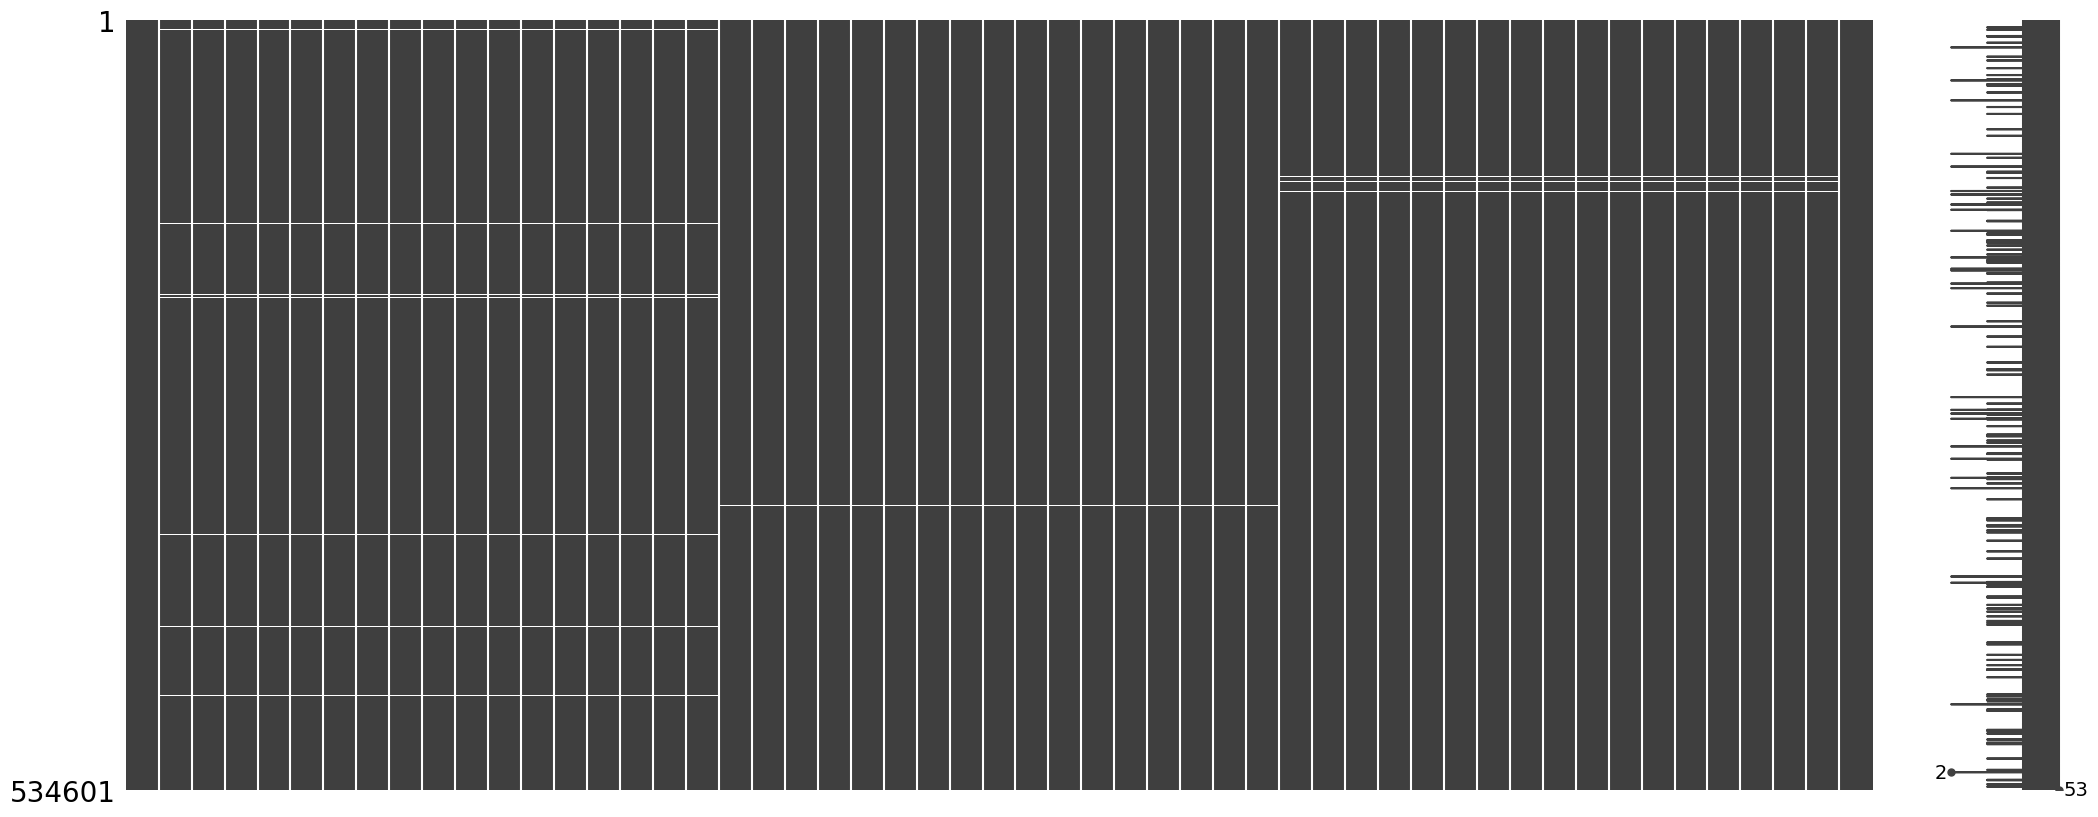

In [10]:
msno.matrix(data)

In [11]:
exclude_cols = ["timestamp", "subject_id"]
sensor_cols = [
    col for col in data.select_dtypes(include=["number"]).columns
    if col not in exclude_cols
]

missing_before = data[sensor_cols].isna().mean().sort_values(ascending=False) * 100

display(
    missing_before[missing_before > 0].to_frame("missing_percentage_before")
)

data[sensor_cols] = data[sensor_cols].fillna(data[sensor_cols].median())

missing_after = data[sensor_cols].isna().mean().sort_values(ascending=False) * 100

display(
    missing_after[missing_after > 0].to_frame("missing_percentage_after")
)

,missing_percentage_before
handTemperature,0.755891
handAcc16_1,0.755891
handAcc16_2,0.755891
handAcc16_3,0.755891
handAcc6_1,0.755891
handAcc6_2,0.755891
handAcc6_3,0.755891
handGyro1,0.755891
handGyro2,0.755891
handGyro3,0.755891


,missing_percentage_after


In [12]:
data[sensor_cols].isna().sum()

,0
handTemperature,0
handAcc16_1,0
handAcc16_2,0
handAcc16_3,0
handAcc6_1,0
handAcc6_2,0
handAcc6_3,0
handGyro1,0
handGyro2,0
handGyro3,0


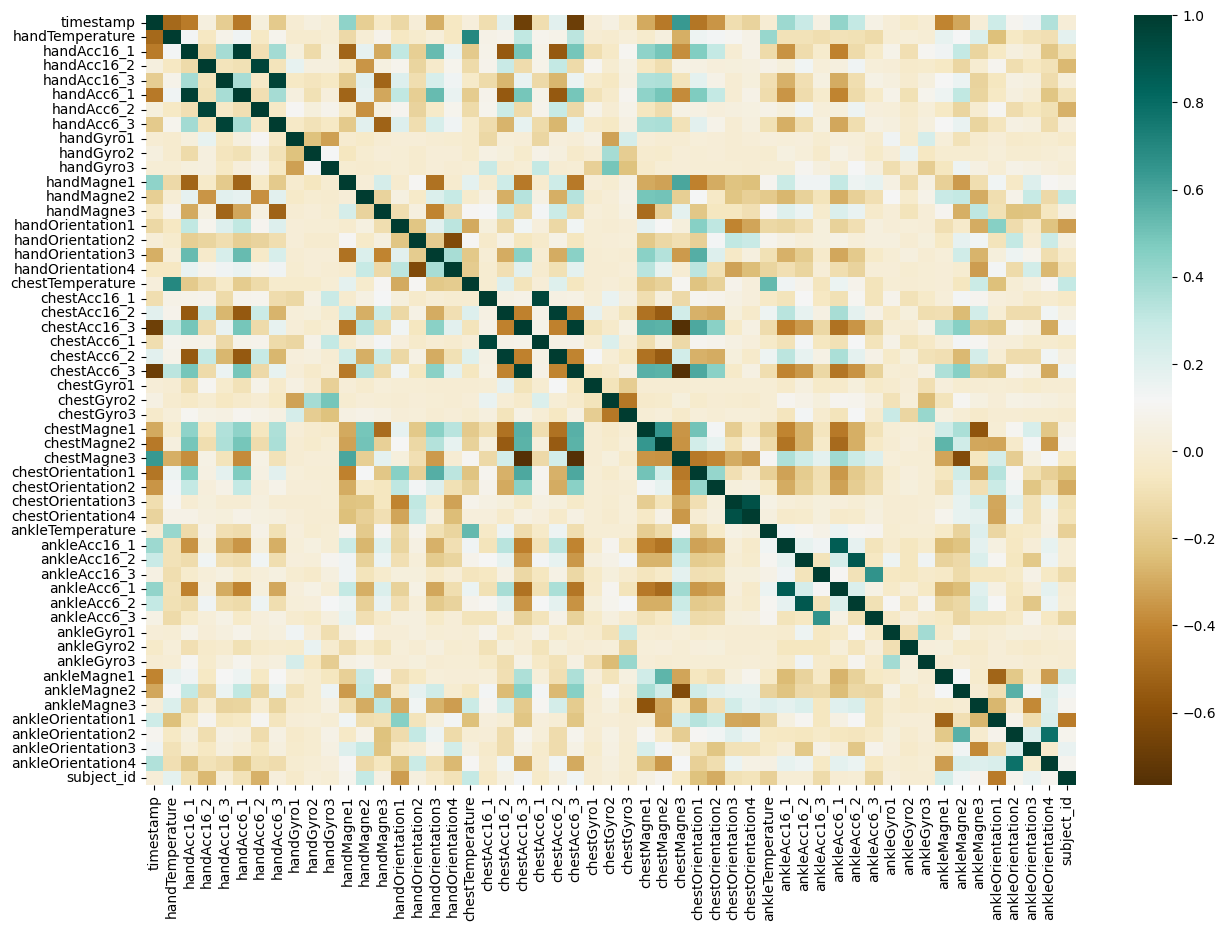

In [13]:
df_corr = data.corr()

f, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(df_corr, mask=np.zeros_like(df_corr, dtype=np.bool), cmap = "BrBG", ax=ax)
plt.show()

In [14]:
df_corr

,timestamp,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,...,ankleGyro2,ankleGyro3,ankleMagne1,ankleMagne2,ankleMagne3,ankleOrientation1,ankleOrientation2,ankleOrientation3,ankleOrientation4,subject_id
timestamp,1.000000,-0.500121,-0.429537,0.037065,-0.184821,-0.439551,0.032859,-0.195678,-0.001748,0.039492,...,-0.037163,-0.001408,-0.405135,-0.307516,0.012852,0.262507,0.093140,0.143269,0.347857,0.012036
handTemperature,-0.500121,1.000000,0.128009,-0.062848,0.070999,0.141074,-0.053354,0.088161,-0.017746,-0.015138,...,0.018965,0.005133,0.167963,0.117138,0.214288,-0.241265,-0.050768,-0.085076,-0.102895,0.183299
handAcc16_1,-0.429537,0.128009,1.000000,-0.119293,0.371950,0.981444,-0.104240,0.379073,0.027872,-0.122935,...,-0.099674,0.096433,0.143215,0.297843,-0.151033,-0.050083,0.038580,0.003715,-0.213523,-0.090674
handAcc16_2,0.037065,-0.062848,-0.119293,1.000000,-0.078166,-0.094128,0.964042,-0.078688,0.170184,0.035170,...,-0.030691,-0.025141,-0.051817,-0.145747,-0.009348,0.089851,-0.109594,-0.060793,-0.087700,-0.258814
handAcc16_3,-0.184821,0.070999,0.371950,-0.078166,1.000000,0.365683,-0.048545,0.972070,-0.049480,-0.076511,...,-0.020330,0.038267,0.113886,0.157804,-0.153771,-0.069092,0.051890,0.040578,-0.115574,0.017061
handAcc6_1,-0.439551,0.141074,0.981444,-0.094128,0.365683,1.000000,-0.097781,0.373652,0.039073,-0.096294,...,-0.096859,0.082436,0.144535,0.302994,-0.146894,-0.054640,0.038529,0.005762,-0.216044,-0.089387
handAcc6_2,0.032859,-0.053354,-0.104240,0.964042,-0.048545,-0.097781,1.000000,-0.045684,0.103628,0.027172,...,-0.031324,0.013158,-0.055804,-0.151343,-0.008353,0.095819,-0.114560,-0.064436,-0.091935,-0.277545
handAcc6_3,-0.195678,0.088161,0.379073,-0.078688,0.972070,0.373652,-0.045684,1.000000,-0.044156,-0.088736,...,-0.019837,0.040055,0.115660,0.164118,-0.149979,-0.074551,0.053555,0.040096,-0.116286,0.024302
handGyro1,-0.001748,-0.017746,0.027872,0.170184,-0.049480,0.039073,0.103628,-0.044156,1.000000,-0.235322,...,-0.024986,0.240219,0.019459,-0.087266,-0.014794,0.010198,-0.034819,-0.024423,-0.010484,-0.029282
handGyro2,0.039492,-0.015138,-0.122935,0.035170,-0.076511,-0.096294,0.027172,-0.088736,-0.235322,1.000000,...,0.162989,-0.062377,-0.011531,-0.008466,-0.012826,0.013852,-0.008276,-0.012033,-0.000571,0.013235


**Выводы:** в данных не обнаружено дубликатов строк.

Пропущенные значения обнаружены в 51 признаке, то есть почти во всех сенсорных измерениях. Однако доля пропусков невысокая: для датчиков руки около 0.76%, для датчиков лодыжки около 0.48%, для датчиков груди около 0.15%.

На графике matrix видим, что пропуски не случайные точками, а идут блоками. Скорее всего, в определённые моменты времени один из датчиков временно не записывал данные. Например, если пропущены сразу несколько колонок руки, значит проблема не в одной переменной, а в блоке sensor data.

Так как пропусков мало, удаление строк не является оптимальным решением: это привело бы к потере части временного ряда. Поэтому для дальнейшей обработки используется заполнение пропусков медианными значениями. Медиана выбрана потому, что она более устойчива к выбросам, которые присутствуют в данных IMU-сенсоров.

По корреляционной матрице видно, что очень сильные корреляции между некоторыми парами признаков. Например:

handAcc16_1 и handAcc6_1 ≈ 0.98
handAcc16_2 и handAcc6_2 ≈ 0.96
handAcc16_3 и handAcc6_3 ≈ 0.97

## 3. Feature Engineering

Создадим дополнительные признаки: модуль ускорения, модуль гироскопа, модуль магнитометра, энергия сигнала и различия между движением руки, груди и лодыжки.

In [15]:
parts = ["hand", "chest", "ankle"]

for part in parts:
    data[f"{part}Acc16_mag"] = np.sqrt(
        data[f"{part}Acc16_1"]**2 +
        data[f"{part}Acc16_2"]**2 +
        data[f"{part}Acc16_3"]**2
    )

    data[f"{part}Acc6_mag"] = np.sqrt(
        data[f"{part}Acc6_1"]**2 +
        data[f"{part}Acc6_2"]**2 +
        data[f"{part}Acc6_3"]**2
    )

    data[f"{part}Gyro_mag"] = np.sqrt(
        data[f"{part}Gyro1"]**2 +
        data[f"{part}Gyro2"]**2 +
        data[f"{part}Gyro3"]**2
    )

    data[f"{part}Magne_mag"] = np.sqrt(
        data[f"{part}Magne1"]**2 +
        data[f"{part}Magne2"]**2 +
        data[f"{part}Magne3"]**2
    )

    data[f"{part}Orientation_mag"] = np.sqrt(
        data[f"{part}Orientation1"]**2 +
        data[f"{part}Orientation2"]**2 +
        data[f"{part}Orientation3"]**2 +
        data[f"{part}Orientation4"]**2
    )

In [16]:
data["hand_chest_acc16_diff"] = abs(data["handAcc16_mag"] - data["chestAcc16_mag"])
data["hand_ankle_acc16_diff"] = abs(data["handAcc16_mag"] - data["ankleAcc16_mag"])
data["chest_ankle_acc16_diff"] = abs(data["chestAcc16_mag"] - data["ankleAcc16_mag"])

data["hand_chest_acc6_diff"] = abs(data["handAcc6_mag"] - data["chestAcc6_mag"])
data["hand_ankle_acc6_diff"] = abs(data["handAcc6_mag"] - data["ankleAcc6_mag"])
data["chest_ankle_acc6_diff"] = abs(data["chestAcc6_mag"] - data["ankleAcc6_mag"])

data["hand_chest_gyro_diff"] = abs(data["handGyro_mag"] - data["chestGyro_mag"])
data["hand_ankle_gyro_diff"] = abs(data["handGyro_mag"] - data["ankleGyro_mag"])
data["chest_ankle_gyro_diff"] = abs(data["chestGyro_mag"] - data["ankleGyro_mag"])

data["hand_chest_magne_diff"] = abs(data["handMagne_mag"] - data["chestMagne_mag"])
data["hand_ankle_magne_diff"] = abs(data["handMagne_mag"] - data["ankleMagne_mag"])
data["chest_ankle_magne_diff"] = abs(data["chestMagne_mag"] - data["ankleMagne_mag"])

data["overall_acc16_mag"] = (
    data["handAcc16_mag"] +
    data["chestAcc16_mag"] +
    data["ankleAcc16_mag"]
) / 3

data["overall_acc6_mag"] = (
    data["handAcc6_mag"] +
    data["chestAcc6_mag"] +
    data["ankleAcc6_mag"]
) / 3

data["overall_gyro_mag"] = (
    data["handGyro_mag"] +
    data["chestGyro_mag"] +
    data["ankleGyro_mag"]
) / 3

data["overall_magne_mag"] = (
    data["handMagne_mag"] +
    data["chestMagne_mag"] +
    data["ankleMagne_mag"]
) / 3

data["hand_chest_temp_diff"] = abs(data["handTemperature"] - data["chestTemperature"])
data["hand_ankle_temp_diff"] = abs(data["handTemperature"] - data["ankleTemperature"])
data["chest_ankle_temp_diff"] = abs(data["chestTemperature"] - data["ankleTemperature"])

data["overall_temperature"] = (
    data["handTemperature"] +
    data["chestTemperature"] +
    data["ankleTemperature"]
) / 3


print("Размер data после feature engineering:", data.shape)

Размер data после feature engineering: (534601, 88)


In [17]:
data.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
timestamp,1593.538159,1243.906483,37.66000,4007.730000
handTemperature,32.454424,1.748587,27.50000,35.250000
handAcc16_1,-4.443074,7.035828,-114.75500,60.912600
handAcc16_2,3.240794,7.196689,-82.55090,155.532000
handAcc16_3,4.079963,3.816756,-73.94970,78.480100
...,...,...,...,...
overall_magne_mag,44.760668,13.740608,20.50749,140.745940
hand_chest_temp_diff,3.415479,1.281636,0.31250,8.250000
hand_ankle_temp_diff,1.353936,1.390853,0.00000,6.250000
chest_ankle_temp_diff,2.398577,1.261060,0.00000,5.937500


In [18]:
drop_cols = [
    "timestamp",
    "subject_id",
    "index",
    "Index",
    "cluster",
    "activityID",
    "label",
    "new_label"
]

features = [
    col for col in data.select_dtypes(include=["number"]).columns
    if col not in drop_cols
]

X = data[features].copy()

In [19]:
lower = X.quantile(0.005)
upper = X.quantile(0.995)

X_clipped = X.clip(lower=lower, upper=upper, axis=1)

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clipped)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Размер X_scaled_df:", X_scaled_df.shape)

display(
    X_scaled_df.describe().T[["mean", "std", "min", "max"]].head(20)
)

Размер X_scaled_df: (534601, 86)


,mean,std,min,max
handTemperature,-1.756975e-15,1.000001,-2.587061,1.600363
handAcc16_1,1.167090e-16,1.000001,-3.462902,2.290410
handAcc16_2,7.501488e-17,1.000001,-3.549831,6.206429
handAcc16_3,5.499851e-17,1.000001,-3.479364,2.395325
handAcc6_1,1.874575e-16,1.000001,-3.482901,2.255236
handAcc6_2,-3.694257e-17,1.000001,-3.566507,6.259040
handAcc6_3,1.160046e-16,1.000001,-3.490877,2.301263
handGyro1,1.495247e-18,1.000001,-4.595296,4.173048
handGyro2,3.635112e-18,1.000001,-3.844805,4.430480
handGyro3,2.365813e-18,1.000001,-4.527052,3.833142


**Выводы**: после feature engineering количество признаков увеличилось с 53 до 86. Сырые данные IMU содержат измерения по трём осям для акселерометра, гироскопа и магнитометра. На их основе были созданы признаки-модули, отражающие общую интенсивность движения для руки, груди и лодыжки.

Анализ описательной статистики показал, что исходные признаки находятся в разных масштабах. Например, временная метка имеет стандартное отклонение более 1200, признаки магнитометра — около 17–24, признаки акселерометра — около 3–8, а некоторые признаки гироскопа имеют стандартное отклонение меньше 1. Это означает, что без масштабирования признаки с большим разбросом могли бы сильнее влиять на расстояния между объектами.

Так как задача решается методами кластеризации, основанными на расстояниях между объектами, признаки необходимо привести к единому масштабу. Перед масштабированием были исключены признаки timestamp и subject_id. timestamp является временной меткой, а subject_id обозначает участника эксперимента, поэтому их использование могло бы привести к группировке по времени или по человеку, а не по типу активности.

Пропущенные значения были заполнены медианой, так как медиана является устойчивой мерой и меньше зависит от выбросов. После этого признаки были масштабированы с помощью StandardScaler.

Проверка статистик после масштабирования показала, что средние значения признаков стали близки к 0, а стандартные отклонения — близки к 1. Это подтверждает, что масштабирование выполнено корректно.

## 4. Снижение размерности с помощью PCA

In [21]:
pca_check = PCA()
pca_check.fit(X_scaled_df)

print("Первая компонента объясняет:", pca_check.explained_variance_ratio_[0])
print("Первые 10 компонент:")
print(pca_check.explained_variance_ratio_[:10])

Первая компонента объясняет: 0.18989712553759694
Первые 10 компонент:
[0.18989713 0.08336315 0.06587874 0.05929149 0.04968233 0.03944628
 0.03568896 0.03355466 0.03314649 0.02863957]


In [22]:
cumulative_variance = np.cumsum(pca_check.explained_variance_ratio_)

n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_97 = np.argmax(cumulative_variance >= 0.97) + 1

print("Количество компонент для 80%:", n_components_80)
print("Количество компонент для 90%:", n_components_90)
print("Количество компонент для 95%:", n_components_95)
print("Количество компонент для 97%:", n_components_97)

Количество компонент для 80%: 22
Количество компонент для 90%: 32
Количество компонент для 95%: 41
Количество компонент для 97%: 46


In [23]:
pca_97 = PCA(n_components=0.97, random_state=42)
X_pca_97 = pca_97.fit_transform(X_scaled_df)

print("Размер X_pca_97:", X_pca_97.shape)
print("Сохранённая дисперсия:", pca_97.explained_variance_ratio_.sum())

Размер X_pca_97: (534601, 46)
Сохранённая дисперсия: 0.9700823784889959


**Выводы:** для анализа структуры данных и снижения размерности был применён метод PCA. Результаты показали, что первая главная компонента объясняет около 18.99% общей дисперсии данных. Это означает, что данные не сводятся к одному доминирующему направлению и имеют сложную многомерную структуру.

Первые 10 компонент объясняют значительную часть вариативности, однако для сохранения большей части информации требуется большее количество компонент. Анализ накопленной объяснённой дисперсии показал, что для сохранения 80% информации необходимо 22 компоненты, для 90% — 32 компоненты, для 95% — 41 компонента, а для 97% — 46 компонент.

Так как задача кластеризации чувствительна к шуму и размерности признакового пространства, PCA используется для уменьшения количества признаков перед обучением модели. Для дальнейших экспериментов можно протестировать несколько вариантов: PCA с сохранением 90%, 95% и 97% дисперсии. Более высокий процент сохраняет больше информации, но может также сохранять часть шума, поэтому итоговый вариант выбирается по результатам кластеризации и оценке на Kaggle.

## 5. Подбор числа кластеров для K-means

In [24]:
chosen_k = 13

model = MiniBatchKMeans(
    n_clusters=chosen_k,
    random_state=42,
    n_init=20,
    batch_size=8192
)

labels_pca97 = model.fit_predict(X_pca_97)

print("Количество предсказаний:", len(labels_pca97))
print("Уникальные кластеры:", sorted(np.unique(labels_pca97)))

Количество предсказаний: 534601
Уникальные кластеры: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


In [25]:
sample_size = min(50000, len(X_pca_97))

X_pca_sample = pd.DataFrame(X_pca_97).sample(
    n=sample_size,
    random_state=42
)

k_values = range(2, 15)

results = []

for k in k_values:
    model = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
        batch_size=4096
    )

    labels = model.fit_predict(X_pca_sample)

    results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_pca_sample, labels),
        "davies_bouldin": davies_bouldin_score(X_pca_sample, labels),
        "calinski_harabasz": calinski_harabasz_score(X_pca_sample, labels)
    })

scores_pca_97 = pd.DataFrame(results)

display(scores_pca_97)

,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,3.668121e+06,0.244826,2.445730,6875.386938
1,3,3.301995e+06,0.143020,2.187640,6596.836610
2,4,3.080879e+06,0.125059,2.345580,5959.673028
3,5,2.920528e+06,0.140640,2.284447,5396.663007
4,6,2.822348e+06,0.093164,2.233498,4793.854483
5,7,2.686479e+06,0.119586,2.388635,4628.473814
6,8,2.588985e+06,0.135984,2.374203,4408.585186
7,9,2.509138e+06,0.144101,2.367664,4151.829252
8,10,2.459267e+06,0.120779,2.391153,3875.775395
9,11,2.369210e+06,0.143105,2.212642,3807.584548


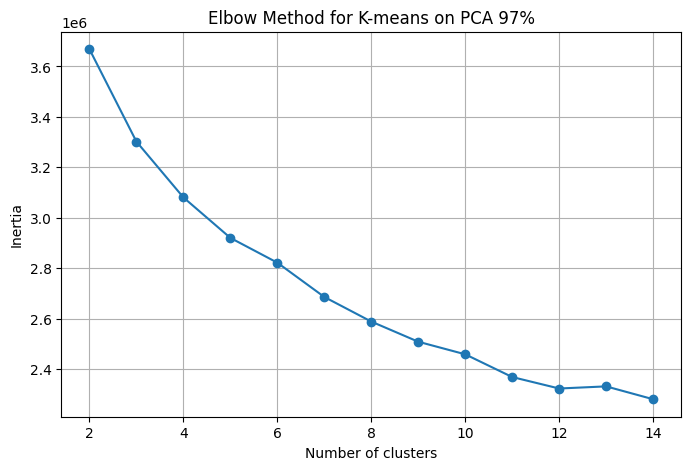

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(scores_pca_97["k"], scores_pca_97["inertia"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-means on PCA 97%")
plt.grid(True)
plt.show()

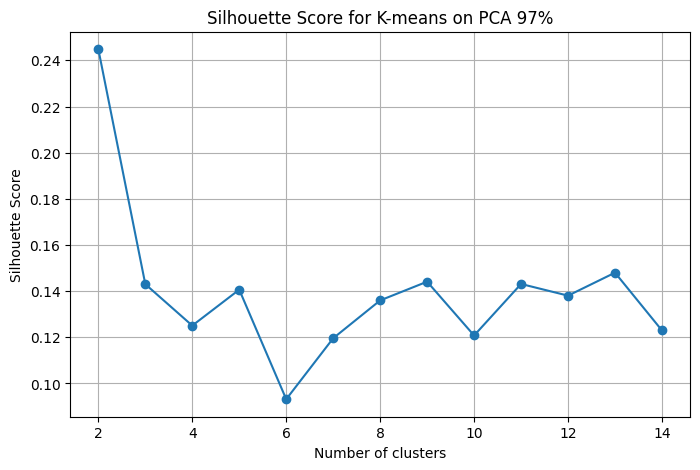

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(scores_pca_97["k"], scores_pca_97["silhouette"], marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K-means on PCA 97%")
plt.grid(True)
plt.show()

In [31]:
chosen_k = 13

gmm = GaussianMixture(
    n_components=chosen_k,
    covariance_type="diag",
    random_state=RANDOM_STATE,
    max_iter=300,
    n_init=5,
    reg_covar=1e-6,
)

raw_clusters = gmm.fit_predict(X_pca_97)

print("Количество предсказаний:", len(raw_clusters))
print("Исходные номера кластеров:", sorted(np.unique(raw_clusters)))

Количество предсказаний: 534601
Исходные номера кластеров: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


In [32]:
assert len(raw_clusters) == len(data), (
    f"Количество предсказаний = {len(raw_clusters)}, "
    f"а количество строк в data = {len(data)}."
)

cluster_counts = (
    pd.Series(raw_clusters)
    .value_counts()
    .sort_index()
    .to_frame("count")
)

cluster_counts["percentage"] = cluster_counts["count"] / len(raw_clusters) * 100

display(cluster_counts)

,count,percentage
0,33170,6.204627
1,73914,13.826012
2,31746,5.938260
3,33732,6.309753
4,59280,11.088644
5,13610,2.545824
6,56954,10.653553
7,13967,2.612603
8,21489,4.019633
9,66651,12.467429


**Выводы**: Хотя silhouette score выше при малом числе кластеров, такое количество кластеров слишком грубо для задачи физической активности. Поэтому финальное значение k=13 выбрано с учётом постановки задачи и ожидаемого количества типов активности

## 6. Функции для Kaggle submission


In [35]:
activity_ids = pd.factorize(raw_clusters)[0] + 1

submission = pd.DataFrame({
    "index": range(len(activity_ids)),
    "activityID": activity_ids
})

display(submission.head())
display(submission.tail())

print("Размер submission:", submission.shape)
print("Уникальные activityID:", sorted(submission["activityID"].unique()))

submission.to_csv("submission_gmm_pca97_k13.csv", index=False)

print("submission_gmm_pca97_k13.csv готов")


,index,activityID
0,0,1
1,1,2
2,2,3
3,3,4
4,4,3


,index,activityID
534596,534596,4
534597,534597,12
534598,534598,6
534599,534599,8
534600,534600,10


Размер submission: (534601, 2)
Уникальные activityID: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13)]
submission_gmm_pca97_k13.csv готов


**Выводы:** финальная модель `GaussianMixture` с `covariance_type="diag"` выбрана потому, что она лучше подходит для данных, где активности могут образовывать не только сферические кластеры. В отличие от KMeans, GMM описывает каждый кластер вероятностно и может гибче разделять группы наблюдений.


## 7. Интерпретация кластеров через профили признаков

Посмотрим, какие признаки сильнее всего различаются между найденными кластерами. Это помогает объяснить, на что ориентировалась модель при разделении активностей.


In [36]:
profile_df = X.copy()
profile_df["activityID"] = activity_ids

cluster_means = profile_df.groupby("activityID").mean()

display(cluster_means.head())


,handTemperature,handAcc16_1,handAcc16_2,handAcc16_3,handAcc6_1,handAcc6_2,handAcc6_3,handGyro1,handGyro2,handGyro3,...,hand_ankle_magne_diff,chest_ankle_magne_diff,overall_acc16_mag,overall_acc6_mag,overall_gyro_mag,overall_magne_mag,hand_chest_temp_diff,hand_ankle_temp_diff,chest_ankle_temp_diff,overall_temperature
activityID,,,,,,,,,,,,,,,,,,,,,
1,33.154319,2.544195,3.229779,7.275105,2.622243,3.240294,7.517137,-0.003472,0.001445,-0.006272,...,3.410676,12.841810,9.774421,9.865515,0.039592,40.853590,2.514750,0.450622,2.965372,33.842362
2,29.036109,-6.224563,1.819870,6.427345,-6.336917,1.773421,6.501551,-0.014416,-0.016304,0.019718,...,11.134943,5.953468,10.324824,10.265652,0.837109,48.506223,5.188506,4.249805,0.948001,32.182213
3,33.263898,-1.342113,3.602210,6.097191,-1.208294,3.607780,6.303764,-0.007344,0.003290,-0.007009,...,8.236153,6.842079,9.815967,9.841834,0.075353,28.104590,2.613600,0.794730,2.238693,34.260067
4,31.916580,-8.369950,2.091841,1.796174,-8.303025,2.138565,1.937134,-0.137756,0.532498,-0.263821,...,11.236355,10.598824,13.133649,13.130968,2.152384,54.270708,3.975707,1.785162,2.421490,33.775634
5,32.249575,-9.533418,2.141275,1.969707,-9.589709,2.168180,2.167556,0.033049,-0.154767,-0.047503,...,6.794013,7.143642,10.600331,10.601544,1.829040,44.456399,4.473701,1.921418,2.829300,34.289137


In [37]:
feature_separation = cluster_means.var(axis=0).sort_values(ascending=False)

display(
    feature_separation
    .head(30)
    .to_frame("variance_between_cluster_means")
)

,variance_between_cluster_means
chestMagne3,452.712069
chestMagne2,366.602503
ankleMagne_mag,325.820227
ankleMagne1,306.686647
handMagne1,296.091737
chestMagne1,178.390798
handMagne2,171.634483
overall_magne_mag,171.381169
ankleMagne2,162.169333
chestMagne_mag,151.404527


In [ ]:
best_features = feature_separation.head(15).index.tolist()

display(cluster_means[best_features])

,chestMagne3,chestMagne2,ankleMagne_mag,ankleMagne1,handMagne1,chestMagne1,handMagne2,overall_magne_mag,ankleMagne2,chestMagne_mag,handMagne_mag,handMagne3,ankleMagne3,hand_ankle_acc16_diff,hand_ankle_magne_diff
activityID,,,,,,,,,,,,,,,
1,-30.305083,7.980937,35.436095,-13.821141,-18.115750,36.287768,5.876192,40.853590,22.124241,48.277905,38.846771,-27.405779,8.131975,0.402718,3.410676
2,35.227521,-18.596852,44.413562,-35.408397,35.632627,6.604001,-4.587911,48.506223,-7.788932,46.036494,55.068612,-33.204079,10.934650,2.928995,11.134943
3,-3.577148,-23.445341,27.472855,-15.815458,5.922282,4.656299,-11.494041,28.104590,0.078899,24.716904,32.124011,-23.915469,19.783554,0.262240,8.236153
4,9.972885,-37.230383,55.239084,-38.525805,29.429414,1.751997,-15.338502,54.270708,-7.337467,50.207628,57.365411,-18.437464,11.754362,7.198906,11.236355
5,5.631769,-34.617637,44.230399,-32.432069,33.607460,2.250248,-9.425629,44.456399,-2.037311,40.545447,48.593351,-19.509762,16.668170,3.908911,6.794013
6,17.091442,-34.061734,47.521580,-36.352081,33.704372,2.546699,-11.210742,48.497611,-1.467770,44.064500,53.906755,-30.105286,17.745860,2.642181,9.422379
7,38.649085,-41.136846,66.377066,-54.187726,18.172655,-1.493850,-31.243563,66.416878,-21.367560,65.237220,67.636347,-44.607413,7.353467,3.633824,6.217173
8,10.789353,-40.712524,51.469844,-35.510542,25.259308,1.412552,-19.755058,50.904772,-2.746742,48.277078,52.967395,-17.781369,14.318801,23.807844,6.818095
9,-8.095540,-59.133555,95.093213,-73.651311,4.497857,-2.096815,-35.716027,78.146449,11.697375,71.622522,67.723612,-24.039081,24.741860,0.355971,27.369602


**Выводы:** анализ дисперсии средних значений между кластерами показал, что наибольший вклад в различие кластеров дают признаки магнитометра: chestMagne3, chestMagne2, ankleMagne_mag, ankleMagne1, handMagne1, chestMagne1, handMagne2 и overall_magne_mag. Это означает, что найденные группы заметно различаются по магнитометрическим измерениям, то есть по ориентации датчиков и положению тела.

По профилям кластеров видно, что отдельные activityID имеют более высокие значения overall_magne_mag и ankleMagne_mag, а также более выраженные различия между рукой и лодыжкой. Кластеры с меньшими значениями разниц между частями тела могут соответствовать более спокойным или стабильным состояниям.

Важно отметить, что в задаче отсутствуют истинные метки активности, поэтому activityID нельзя напрямую назвать конкретными классами вроде “ходьба”, “бег” или “сон”. Полученные номера кластеров отражают группы наблюдений, похожих по структуре сенсорных признаков.


## 8. Скриншот с Kaggle leaderboard
скриншот результата с leaderboard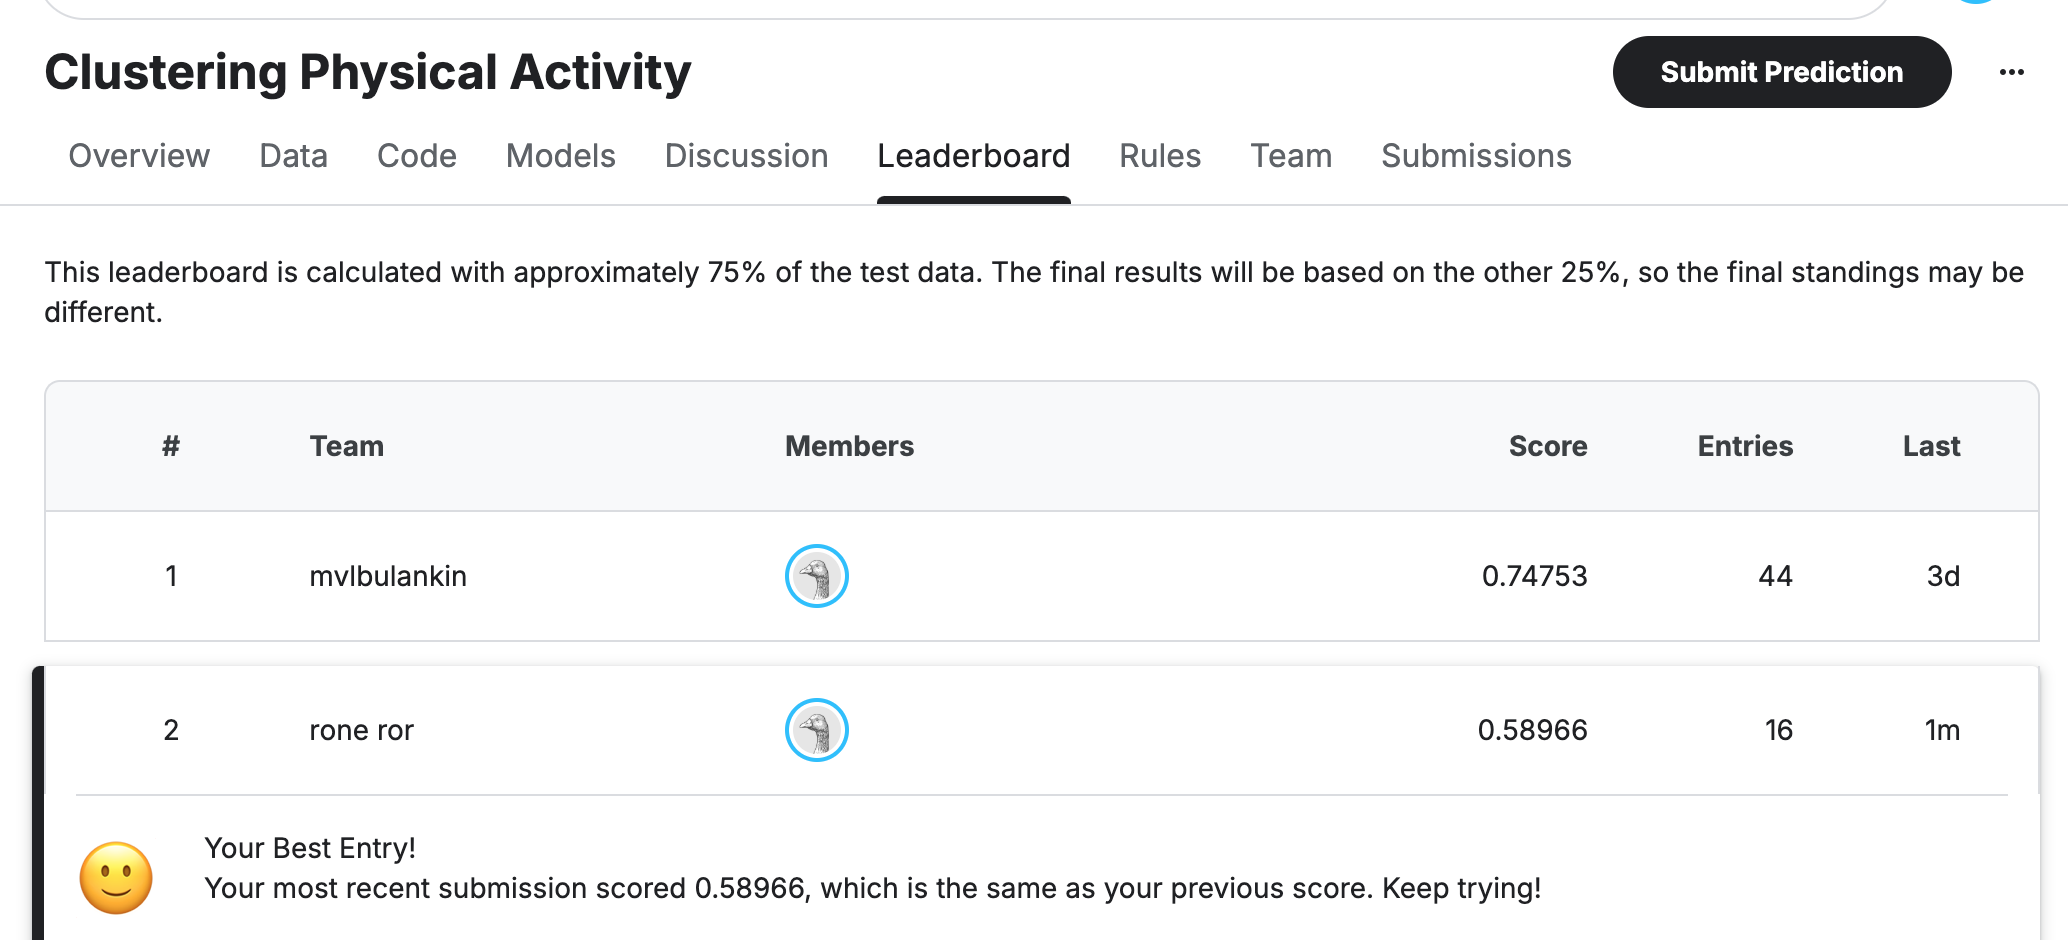


## Финальный вывод

В проекте была выполнена кластеризация данных мониторинга физической активности, собранных с трёх IMU-сенсоров, расположенных на руке, груди и лодыжке.

Основные этапы работы:

1. проведён EDA: проверены размеры данных, типы признаков, пропуски, дубликаты и статистики;
2. выполнен feature engineering на основе физического смысла IMU-данных;
3. выполнена предобработка: заполнение пропусков медианой, масштабирование `StandardScaler`, удаление константных признаков;
4. выполнено снижение размерности через PCA с сохранением 97% дисперсии;
5. протестировано несколько моделей кластеризации: `KMeans`, `MiniBatchKMeans`, `GaussianMixture`, `AgglomerativeClustering`, `DBSCAN`;
6. финальной моделью выбран `GaussianMixture`;
7. сформирован submission.csv